# Evaluation Metrics Overview

This notebook consumes the precomputed summary files in `scripts/opera_log/summary_jsonl` to visualize CHAIR and POPE evaluation metrics across decoding configurations.

In [1]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titleweight": "bold"})

In [2]:
def resolve_paths() -> tuple[Path, Path]:
    start = Path.cwd().resolve()
    for path in [start, *start.parents]:
        summary_dir = path / "opera_log" / "summary_jsonl"
        if summary_dir.exists():
            return path, summary_dir
    raise FileNotFoundError("Cannot locate summary files from current working directory.")


def load_jsonl(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        raise FileNotFoundError(f"Summary file not found: {path}")
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))
    return pd.DataFrame(records)


def format_decoding_label(method: str, variant: str) -> str:
    if not variant or variant in {"baseline", "default"}:
        return method
    pretty_variant = variant.replace("-", " ")
    return f"{method} ({pretty_variant})"


def load_chair_summary(summary_root: Path) -> pd.DataFrame:
    df = load_jsonl(summary_root / "chair_summary.jsonl")
    if df.empty:
        return df
    df["variant"] = df["variant"].fillna("baseline")
    df["metric_variant"] = df["metric_variant"].fillna("default")
    df["decoding"] = df.apply(lambda row: format_decoding_label(row["method"], row["variant"]), axis=1)
    return df


def load_pope_summary(summary_root: Path) -> pd.DataFrame:
    df = load_jsonl(summary_root / "pope_summary.jsonl")
    if df.empty:
        return df
    df["variant"] = df["variant"].fillna("baseline")
    df["metric_variant"] = df["metric_variant"].fillna("default")
    df["decoding"] = df.apply(lambda row: format_decoding_label(row["method"], row["variant"]), axis=1)
    return df


In [3]:
REPO_ROOT, SUMMARY_ROOT = resolve_paths()

print(f"Repository root: {REPO_ROOT}")
print(f"Summary directory: {SUMMARY_ROOT}")

chair_df = load_chair_summary(SUMMARY_ROOT)
pope_df = load_pope_summary(SUMMARY_ROOT)

print(f"Loaded {len(chair_df)} CHAIR metric entries from {SUMMARY_ROOT / 'chair_summary.jsonl'}")
print(f"Loaded {len(pope_df)} POPE metric entries from {SUMMARY_ROOT / 'pope_summary.jsonl'}")

display(chair_df.head())
display(pope_df.head())


Repository root: /Users/mayflower/MayFlower/Deep Learning/Models/Efficient-HA
Summary directory: /Users/mayflower/MayFlower/Deep Learning/Models/Efficient-HA/opera_log/summary_jsonl
Loaded 29 CHAIR metric entries from /Users/mayflower/MayFlower/Deep Learning/Models/Efficient-HA/opera_log/summary_jsonl/chair_summary.jsonl
Loaded 57 POPE metric entries from /Users/mayflower/MayFlower/Deep Learning/Models/Efficient-HA/opera_log/summary_jsonl/pope_summary.jsonl


,dataset,provider,model,method,variant,metric_variant,source,CHAIRs,CHAIRi,Recall,Len,decoding
0,chair,Qwen,Qwen2.5-VL-3B-Instruct,beam,baseline,default,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,0.137725,0.054591,0.447917,0.611517,beam
1,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,alpha_schedule,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,0.120000,0.051125,0.442270,0.611860,deco (10 layers)
2,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,default,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,0.122000,0.049768,0.454664,0.612580,deco (10 layers)
3,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,improved,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,0.098000,0.038540,0.435747,0.604220,deco (10 layers)
4,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,8-layers,improved,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,0.118000,0.047329,0.445532,0.612440,deco (8 layers)


,dataset,provider,model,pope_type,type_alias,method,variant,metric_variant,source,accuracy,...,fn,tn,samples,f1_macro,precision_macro,recall_macro,f1_weighted,precision_weighted,recall_weighted,decoding
0,pope,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,adv,deco,10-layers,improved,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,0.837333,...,330,1170,3000,0.836797,0.841828,0.837333,0.836797,0.841828,0.837333,deco (10 layers)
1,pope,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,adv,greedy,baseline,default,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,0.830667,...,348,1152,3000,0.829999,0.835944,0.830667,0.829999,0.835944,0.830667,greedy
2,pope,Qwen,Qwen2.5-VL-3B-Instruct,popular,pop,deco,10-layers,improved,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,0.876000,...,214,1286,3000,0.875957,0.876525,0.876000,0.875957,0.876525,0.876000,deco (10 layers)
3,pope,Qwen,Qwen2.5-VL-3B-Instruct,popular,pop,greedy,baseline,default,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,0.872667,...,222,1278,3000,0.872612,0.873304,0.872667,0.872612,0.873304,0.872667,greedy
4,pope,Qwen,Qwen2.5-VL-3B-Instruct,random,rand,beam,baseline,default,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,0.920962,...,75,1335,2910,0.920961,0.921578,0.921738,0.920970,0.922370,0.920962,beam


In [4]:
chair_overview = (
    chair_df[
        [
            "dataset",
            "provider",
            "model",
            "method",
            "variant",
            "metric_variant",
            "CHAIRs",
            "CHAIRi",
        ]
    ]
    .sort_values(["provider", "model", "method", "variant", "metric_variant"])
    .reset_index(drop=True)
)

display(chair_overview)


,dataset,provider,model,method,variant,metric_variant,CHAIRs,CHAIRi
0,chair,Qwen,Qwen2.5-VL-3B-Instruct,beam,baseline,default,0.137725,0.054591
1,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,alpha_schedule,0.120000,0.051125
2,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,default,0.122000,0.049768
3,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,improved,0.098000,0.038540
4,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,8-layers,improved,0.118000,0.047329
5,chair,Qwen,Qwen2.5-VL-3B-Instruct,dola,10-layers,default,0.137450,0.061239
6,chair,Qwen,Qwen2.5-VL-3B-Instruct,greedy,baseline,default,0.127943,0.054514
7,chair,google,gemma-3-4b-it,beam,baseline,default,0.048000,0.029621
8,chair,google,gemma-3-4b-it,deco,10-layers,default,0.050881,0.032413
9,chair,google,gemma-3-4b-it,deco,10-layers,improved,0.050000,0.033292


In [5]:
pope_overview = (
    pope_df[
        [
            "dataset",
            "provider",
            "model",
            "pope_type",
            "method",
            "variant",
            "metric_variant",
            "accuracy",
            "f1_weighted",
            "precision_weighted",
            "recall_weighted",
        ]
    ]
    .sort_values(["provider", "model", "pope_type", "method", "variant", "metric_variant"])
    .reset_index(drop=True)
)

display(pope_overview)


,dataset,provider,model,pope_type,method,variant,metric_variant,accuracy,f1_weighted,precision_weighted,recall_weighted
0,pope,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,deco,10-layers,improved,0.837333,0.836797,0.841828,0.837333
1,pope,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,greedy,baseline,default,0.830667,0.829999,0.835944,0.830667
2,pope,Qwen,Qwen2.5-VL-3B-Instruct,popular,deco,10-layers,improved,0.876000,0.875957,0.876525,0.876000
3,pope,Qwen,Qwen2.5-VL-3B-Instruct,popular,greedy,baseline,default,0.872667,0.872612,0.873304,0.872667
4,pope,Qwen,Qwen2.5-VL-3B-Instruct,random,beam,baseline,default,0.920962,0.920970,0.922370,0.920962
5,pope,Qwen,Qwen2.5-VL-3B-Instruct,random,deco,10-layers,improved,0.921993,0.921994,0.923721,0.921993
6,pope,Qwen,Qwen2.5-VL-3B-Instruct,random,greedy,baseline,default,0.919931,0.919930,0.921731,0.919931
7,pope,google,gemma-3-4b-it,adversarial,beam,baseline,default,0.795000,0.793840,0.801790,0.795000
8,pope,google,gemma-3-4b-it,adversarial,deco,10-layers,improved,0.794333,0.793085,0.801611,0.794333
9,pope,google,gemma-3-4b-it,adversarial,dola,10-layers,default,0.787667,0.785894,0.797522,0.787667


In [6]:
chair_table = (
    chair_df
    .sort_values(["metric_variant", "provider", "model", "method", "variant"])    [["metric_variant", "provider", "model", "method", "variant", "CHAIRs", "CHAIRi"]]
)

def display_chair_tables(df: pd.DataFrame):
    for metric_variant, subset in df.groupby("metric_variant"):
        styled = (
            subset.drop(columns="metric_variant")
            .reset_index(drop=True)
            .style
            .format({"CHAIRs": "{:.3f}", "CHAIRi": "{:.3f}"})
            .set_caption(f"Table 1.{metric_variant}: CHAIR metrics — metric_variant = {metric_variant}")
        )
        display(styled)


display_chair_tables(chair_table)


,provider,model,method,variant,CHAIRs,CHAIRi
0,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,0.120,0.051


,provider,model,method,variant,CHAIRs,CHAIRi
0,Qwen,Qwen2.5-VL-3B-Instruct,beam,baseline,0.138,0.055
1,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,0.122,0.050
2,Qwen,Qwen2.5-VL-3B-Instruct,dola,10-layers,0.137,0.061
3,Qwen,Qwen2.5-VL-3B-Instruct,greedy,baseline,0.128,0.055
4,google,gemma-3-4b-it,beam,baseline,0.048,0.030
5,google,gemma-3-4b-it,deco,10-layers,0.051,0.032
6,google,gemma-3-4b-it,dola,10-layers,0.052,0.036
7,google,gemma-3-4b-it,greedy,baseline,0.048,0.029
8,google,gemma-3n-E2B-it,beam,baseline,0.140,0.069
9,google,gemma-3n-E2B-it,deco,10-layers,0.132,0.063


,provider,model,method,variant,CHAIRs,CHAIRi
0,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,0.098,0.039
1,Qwen,Qwen2.5-VL-3B-Instruct,deco,8-layers,0.118,0.047
2,google,gemma-3-4b-it,deco,10-layers,0.050,0.033
3,google,gemma-3n-E2B-it,deco,10-layers,0.120,0.063
4,google,gemma-3n-E4B-it,deco,10-layers,0.124,0.066
5,google,gemma-3n-E4B-it,deco,8-layers,0.124,0.063
6,llava-hf,llava-1.5-7b-hf,deco,8-layers,0.226,0.071


/var/folders/95/vt09lfvd6pz6h9j32x9wlndm0000gn/T/ipykernel_71009/27183571.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


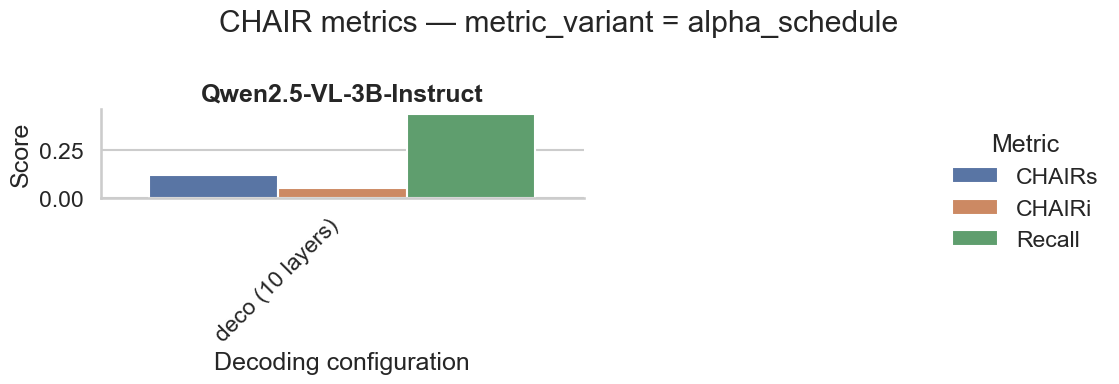

/var/folders/95/vt09lfvd6pz6h9j32x9wlndm0000gn/T/ipykernel_71009/27183571.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/var/folders/95/vt09lfvd6pz6h9j32x9wlndm0000gn/T/ipykernel_71009/27183571.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


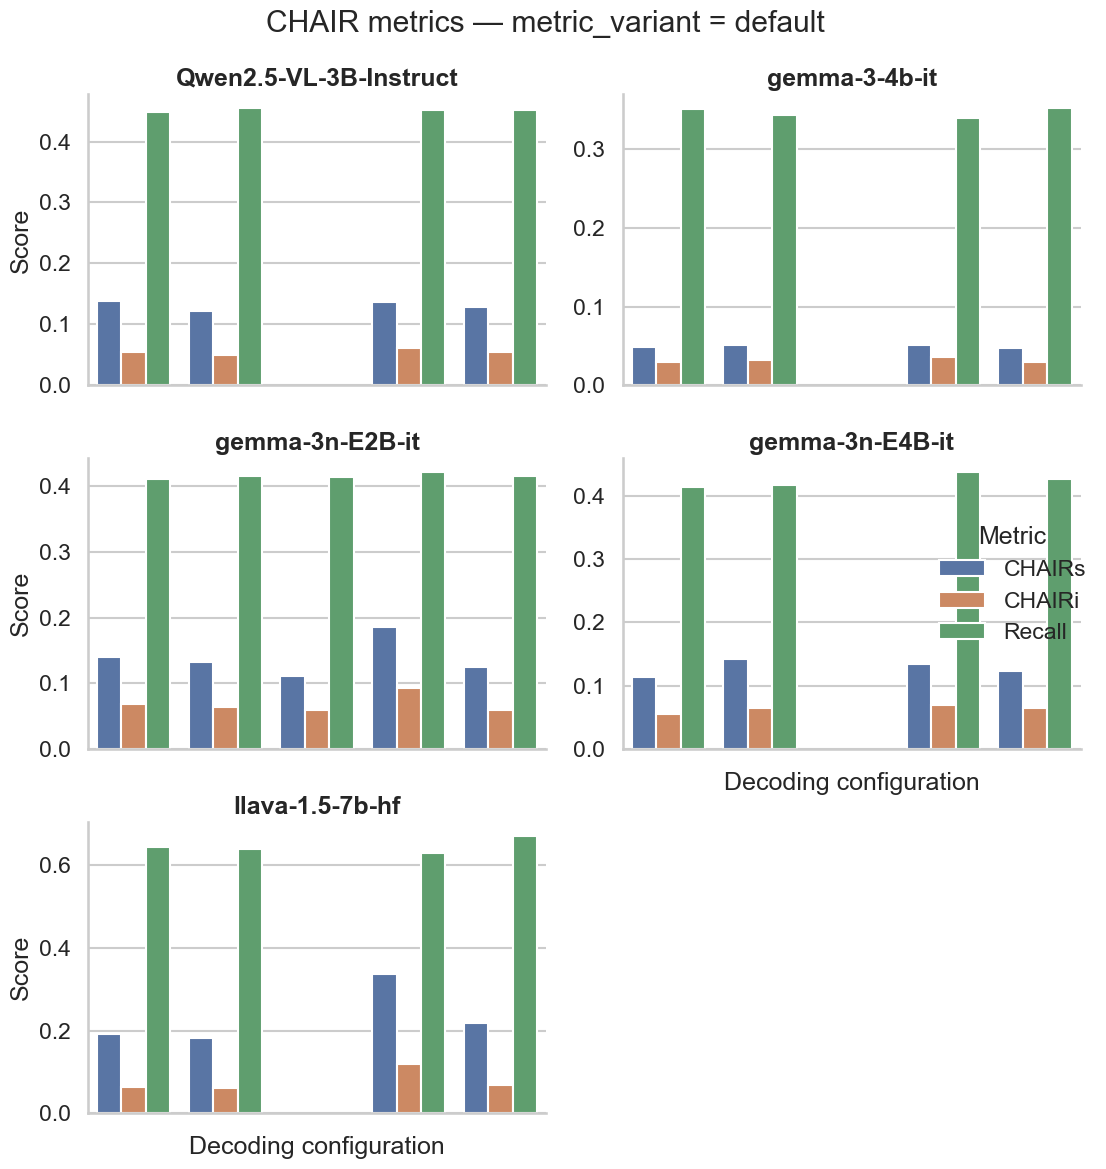

/var/folders/95/vt09lfvd6pz6h9j32x9wlndm0000gn/T/ipykernel_71009/27183571.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/var/folders/95/vt09lfvd6pz6h9j32x9wlndm0000gn/T/ipykernel_71009/27183571.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


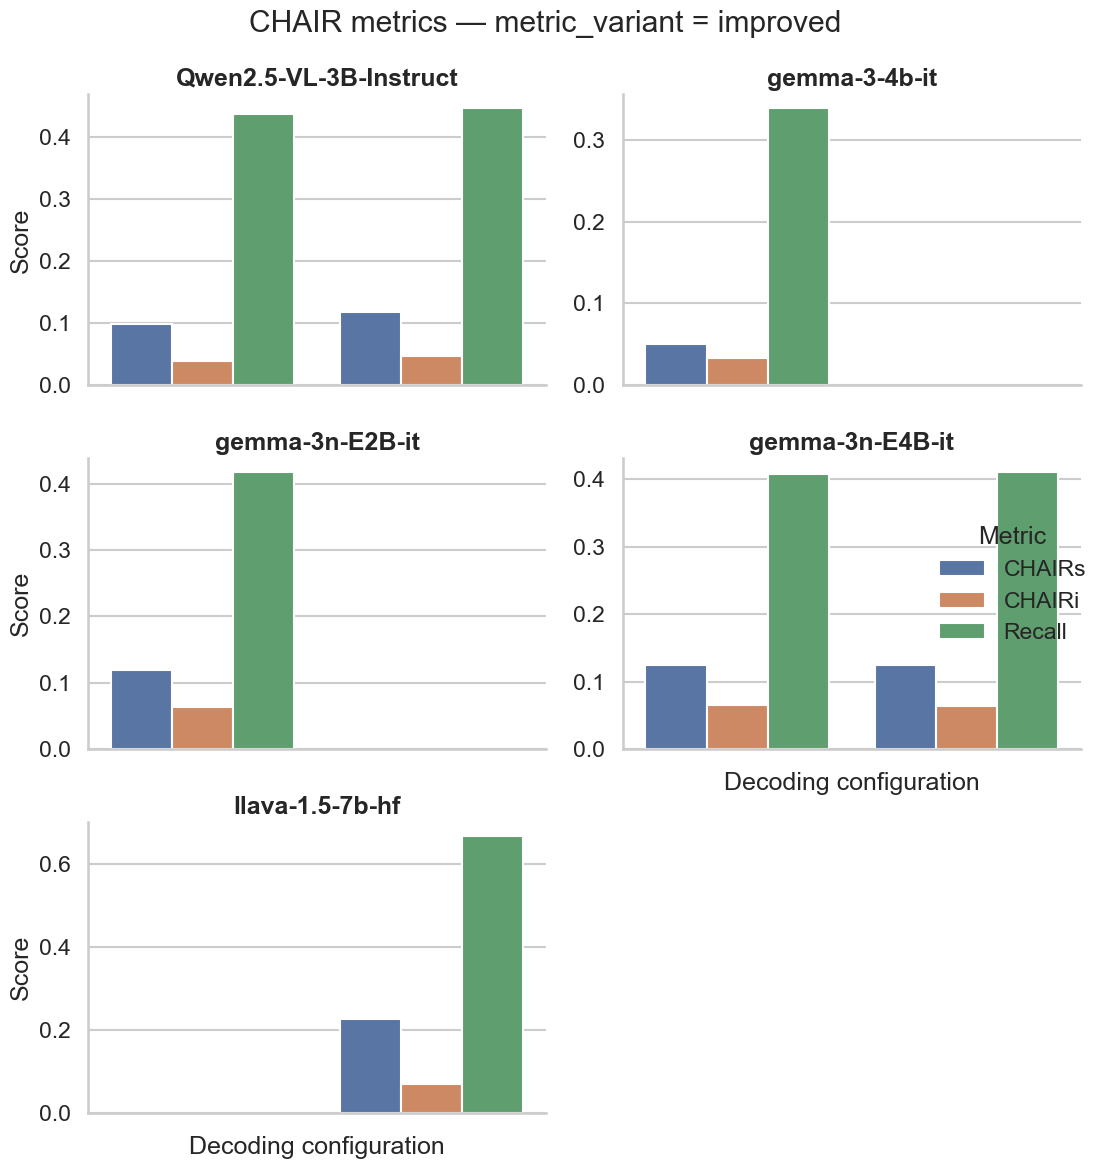

In [7]:
for metric_variant, subset in chair_df.groupby("metric_variant"):
    chair_long = subset.melt(
        id_vars=["provider", "model", "decoding"],
        value_vars=["CHAIRs", "CHAIRi", "Recall"],
        var_name="metric",
        value_name="score",
    )

    order = sorted(subset["decoding"].unique(), key=str.lower)
    g = sns.catplot(
        data=chair_long,
        kind="bar",
        x="decoding",
        y="score",
        hue="metric",
        col="model",
        col_wrap=2,
        order=order,
        height=4,
        aspect=1.2,
        sharey=False,
    )
    g.set_axis_labels("Decoding configuration", "Score")
    g.set_titles("{col_name}")
    if g._legend is not None:
        g._legend.set_title("Metric")
    for ax in g.axes.flatten():
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f"CHAIR metrics — metric_variant = {metric_variant}")
    plt.tight_layout()
    plt.show()


In [8]:
pope_table = (
    pope_df
    .sort_values(["metric_variant", "provider", "model", "pope_type", "method", "variant"])
    [[
        "metric_variant",
        "provider",
        "model",
        "pope_type",
        "method",
        "variant",
        "accuracy",
        "f1_weighted",
        "precision_weighted",
        "recall_weighted",
    ]]
)


def display_pope_tables(df: pd.DataFrame):
    for metric_variant, subset in df.groupby("metric_variant"):
        styled = (
            subset.drop(columns="metric_variant")
            .reset_index(drop=True)
            .style
            .format({
                "accuracy": "{:.3f}",
                "f1_weighted": "{:.3f}",
                "precision_weighted": "{:.3f}",
                "recall_weighted": "{:.3f}",
            })
            .set_caption(f"Table 2.{metric_variant}: POPE metrics — metric_variant = {metric_variant}")
        )
        display(styled)


display_pope_tables(pope_table)


,provider,model,pope_type,method,variant,accuracy,f1_weighted,precision_weighted,recall_weighted
0,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,greedy,baseline,0.831,0.830,0.836,0.831
1,Qwen,Qwen2.5-VL-3B-Instruct,popular,greedy,baseline,0.873,0.873,0.873,0.873
2,Qwen,Qwen2.5-VL-3B-Instruct,random,beam,baseline,0.921,0.921,0.922,0.921
3,Qwen,Qwen2.5-VL-3B-Instruct,random,greedy,baseline,0.920,0.920,0.922,0.920
4,google,gemma-3-4b-it,adversarial,beam,baseline,0.795,0.794,0.802,0.795
5,google,gemma-3-4b-it,adversarial,dola,10-layers,0.788,0.786,0.798,0.788
6,google,gemma-3-4b-it,adversarial,greedy,baseline,0.794,0.793,0.802,0.794
7,google,gemma-3-4b-it,popular,beam,baseline,0.797,0.796,0.803,0.797
8,google,gemma-3-4b-it,popular,dola,10-layers,0.791,0.789,0.800,0.791
9,google,gemma-3-4b-it,popular,greedy,baseline,0.798,0.797,0.804,0.798


,provider,model,pope_type,method,variant,accuracy,f1_weighted,precision_weighted,recall_weighted
0,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,deco,10-layers,0.837,0.837,0.842,0.837
1,Qwen,Qwen2.5-VL-3B-Instruct,popular,deco,10-layers,0.876,0.876,0.877,0.876
2,Qwen,Qwen2.5-VL-3B-Instruct,random,deco,10-layers,0.922,0.922,0.924,0.922
3,google,gemma-3-4b-it,adversarial,deco,10-layers,0.794,0.793,0.802,0.794
4,google,gemma-3-4b-it,popular,deco,10-layers,0.798,0.797,0.804,0.798
5,google,gemma-3-4b-it,random,deco,10-layers,0.845,0.845,0.846,0.845
6,google,gemma-3n-E2B-it,adversarial,deco,10-layers,0.826,0.826,0.829,0.826
7,google,gemma-3n-E2B-it,popular,deco,10-layers,0.837,0.837,0.839,0.837
8,google,gemma-3n-E2B-it,random,deco,10-layers,0.870,0.870,0.870,0.870
9,google,gemma-3n-E4B-it,adversarial,deco,10-layers,0.830,0.830,0.831,0.830


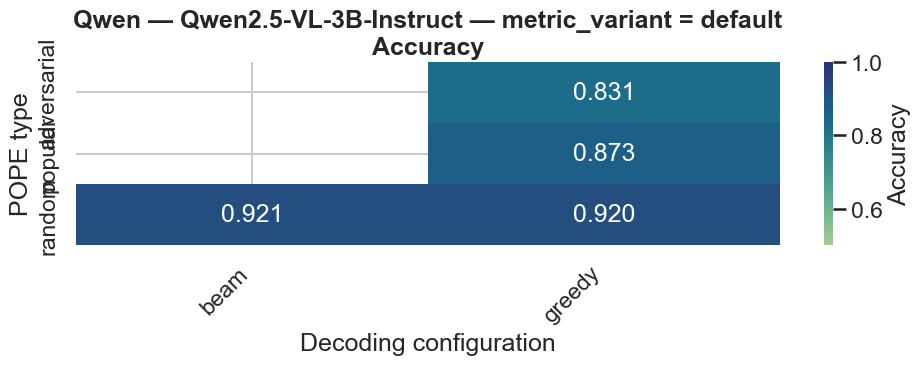

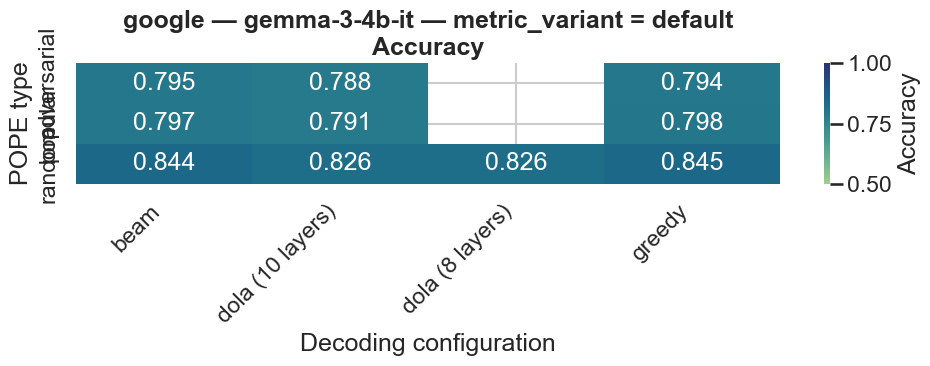

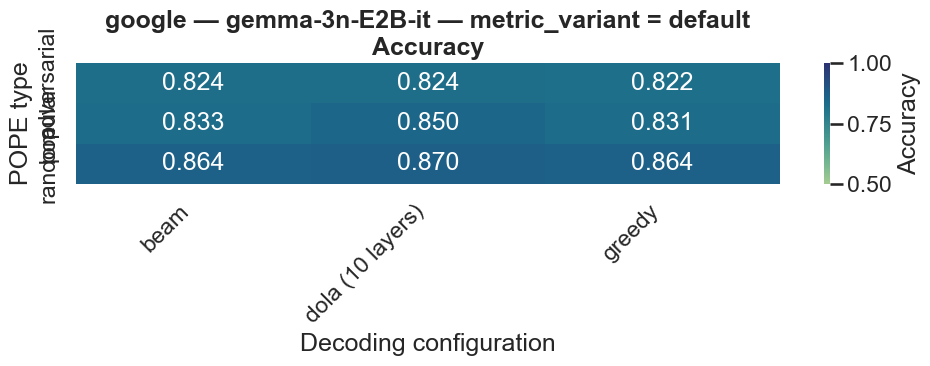

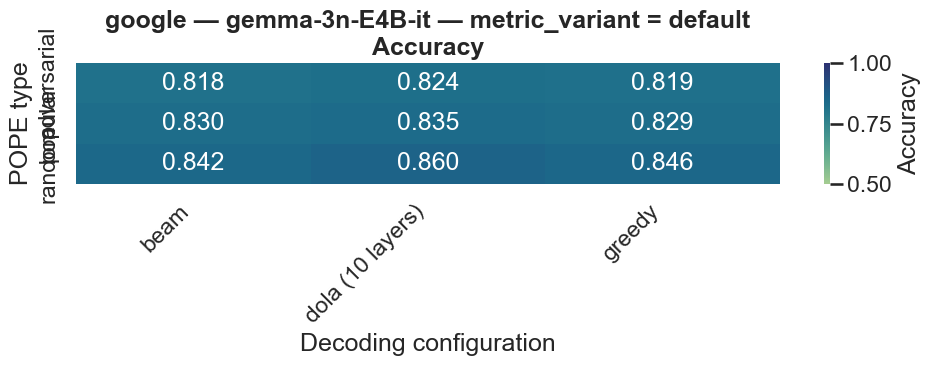

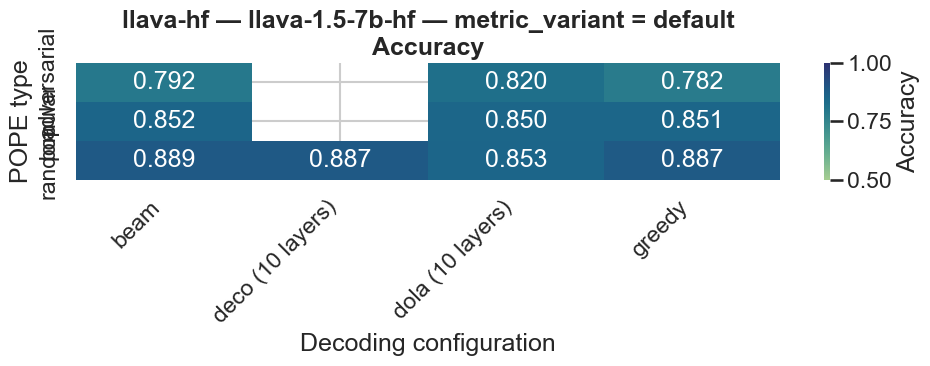

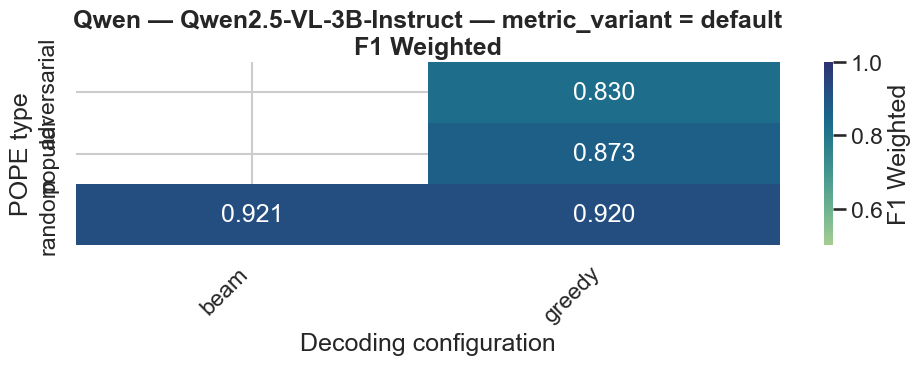

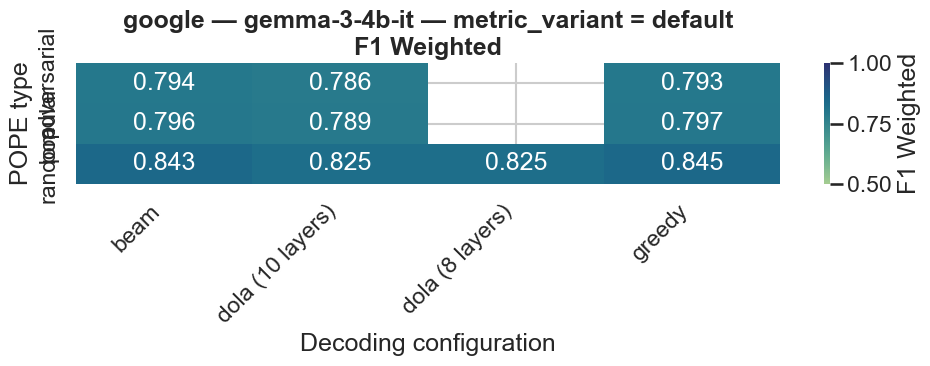

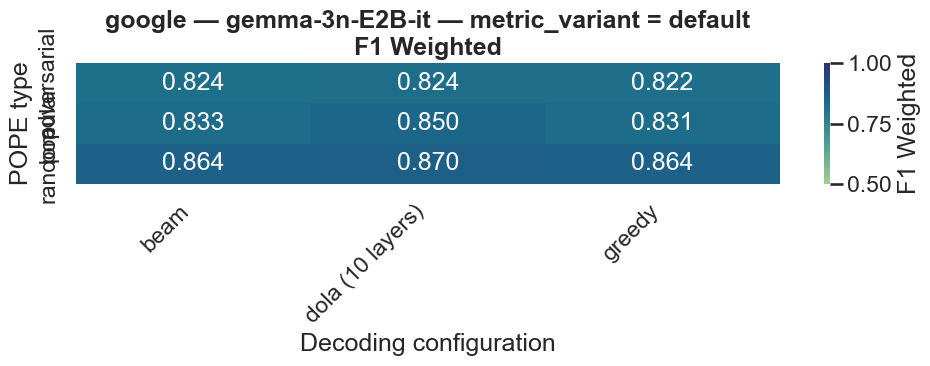

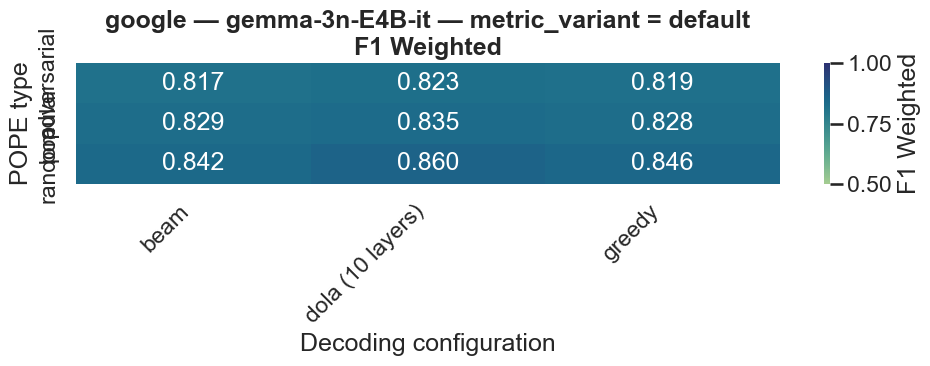

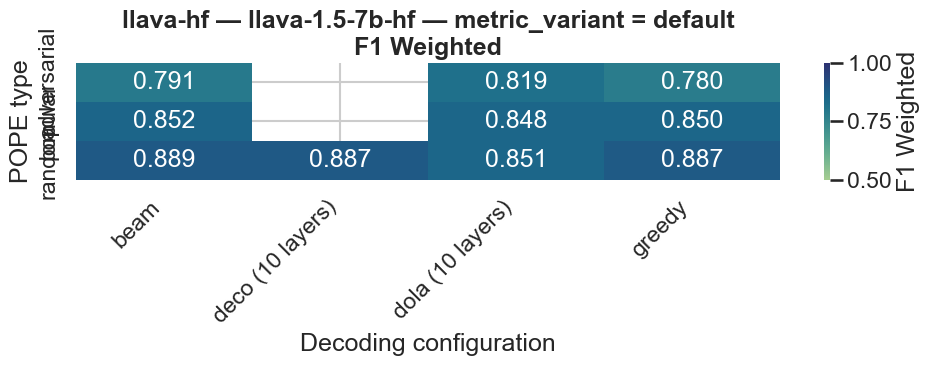

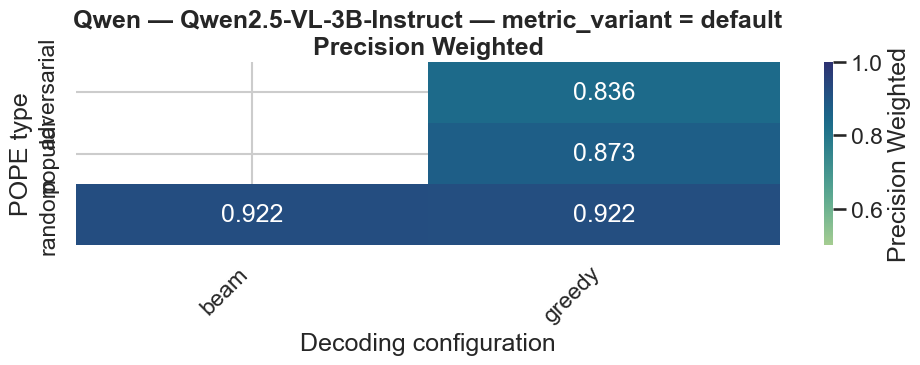

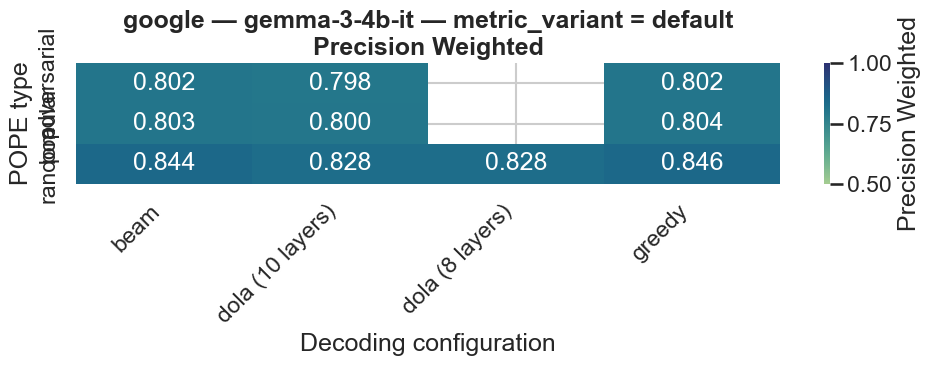

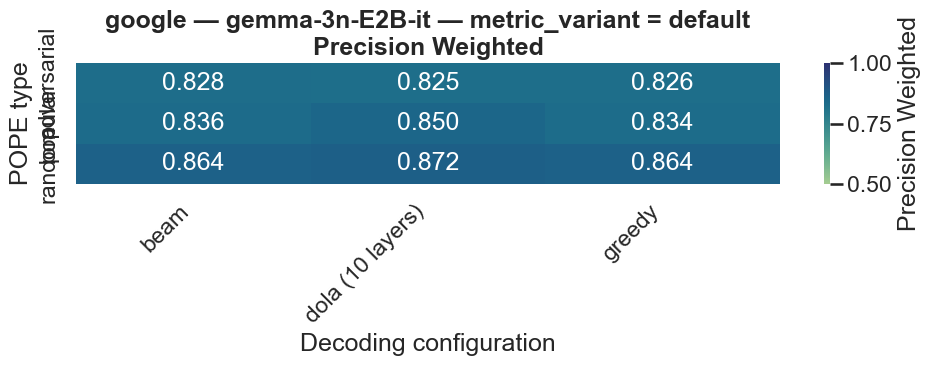

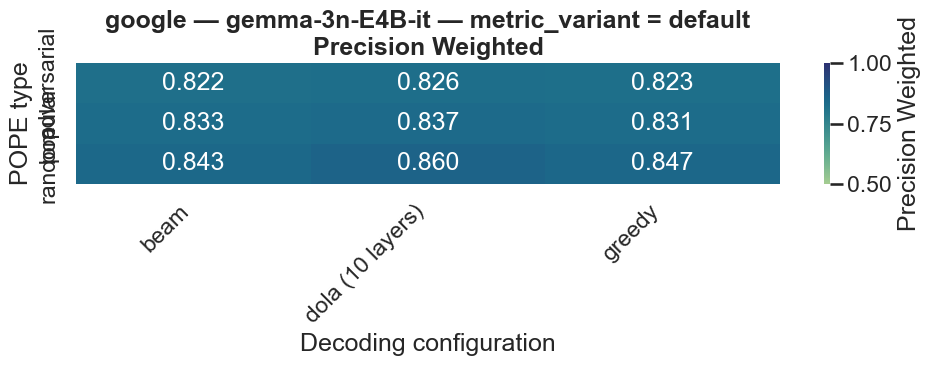

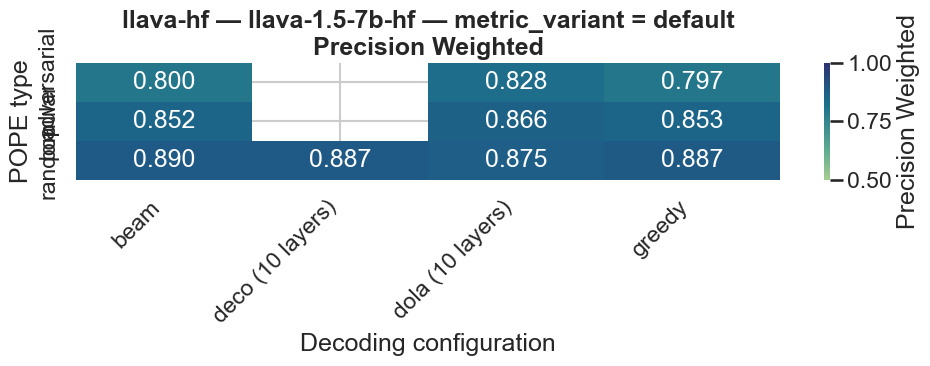

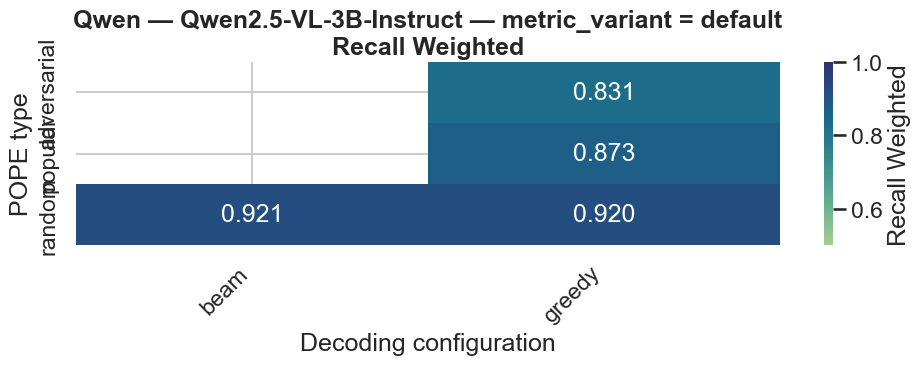

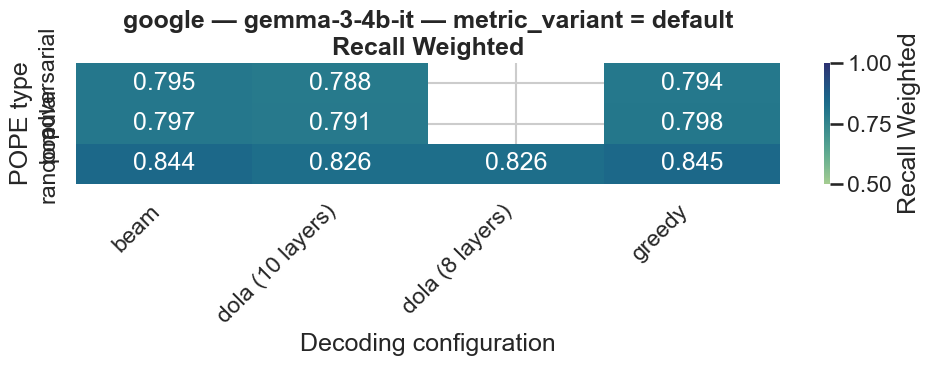

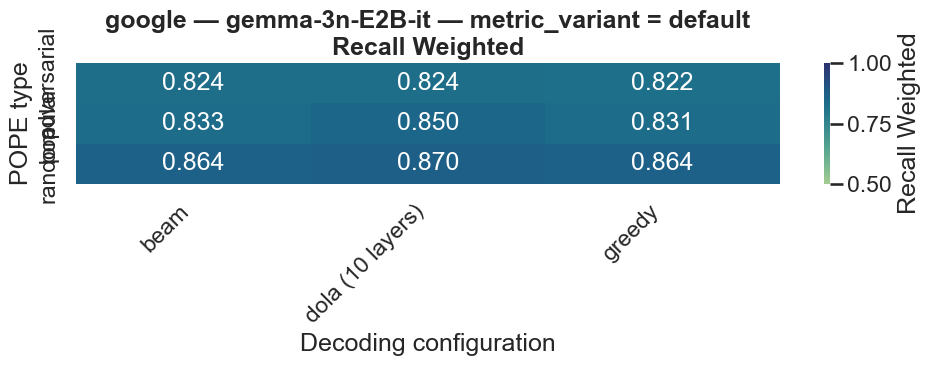

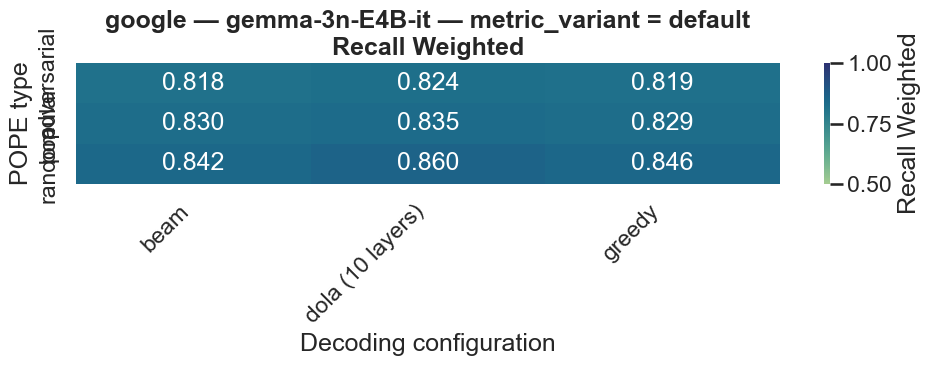

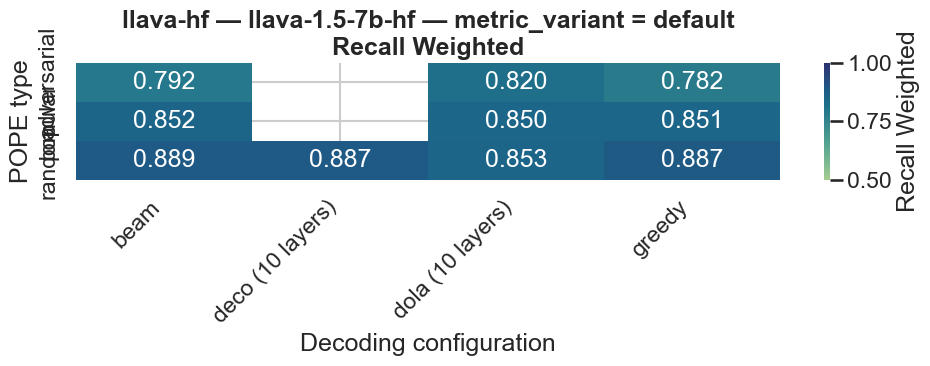

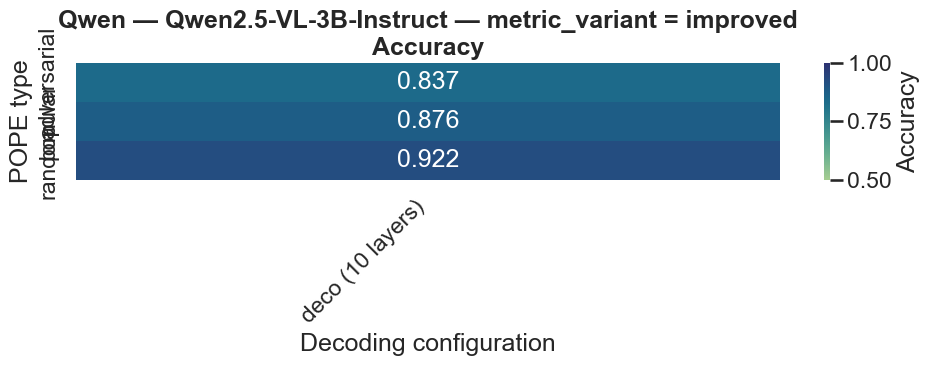

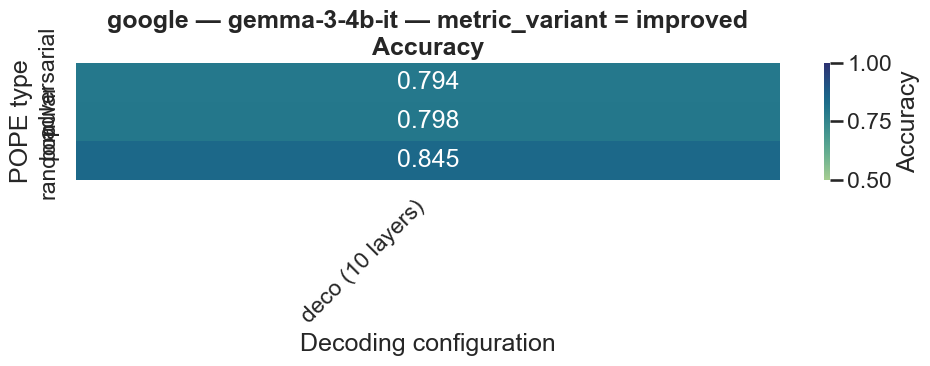

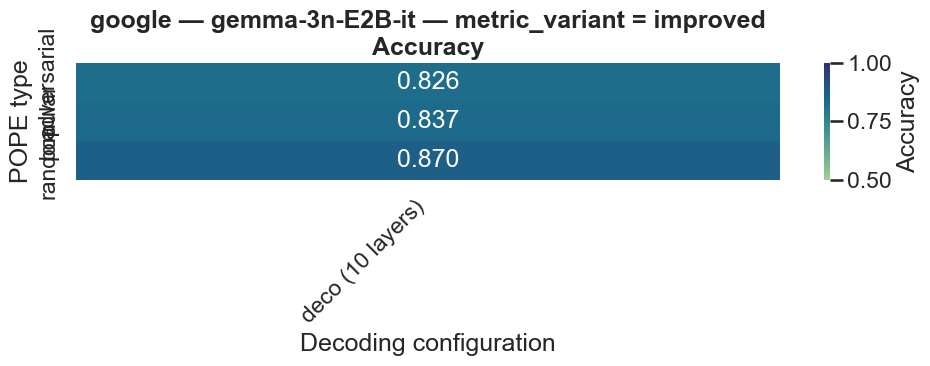

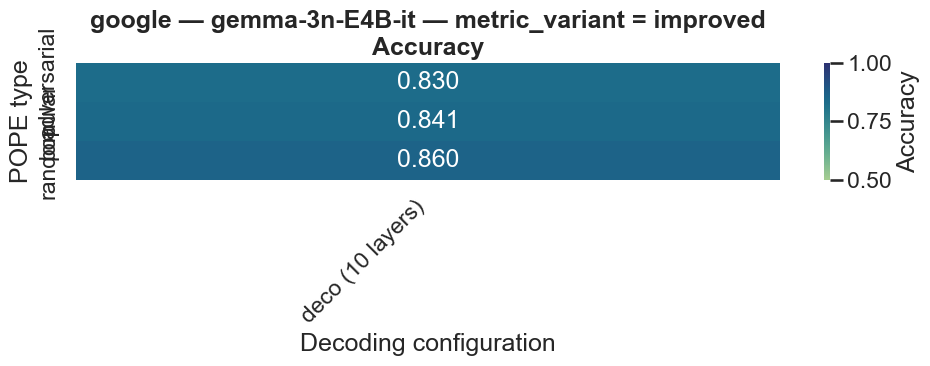

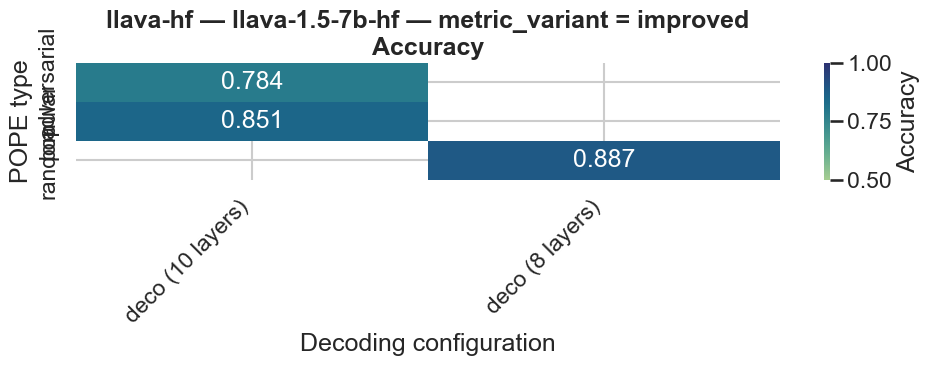

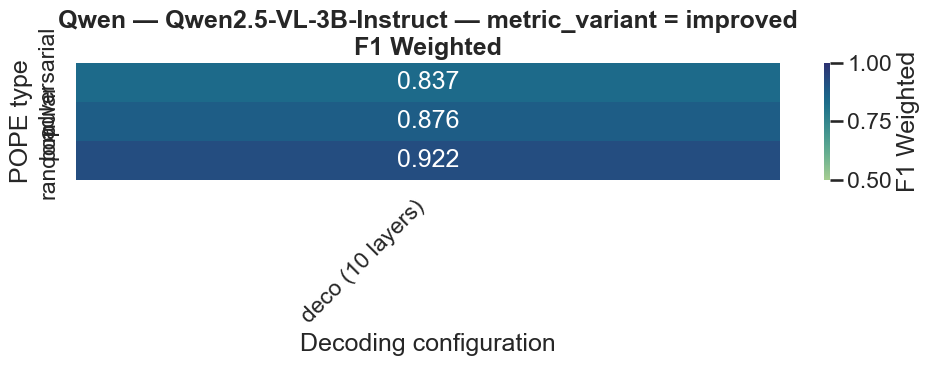

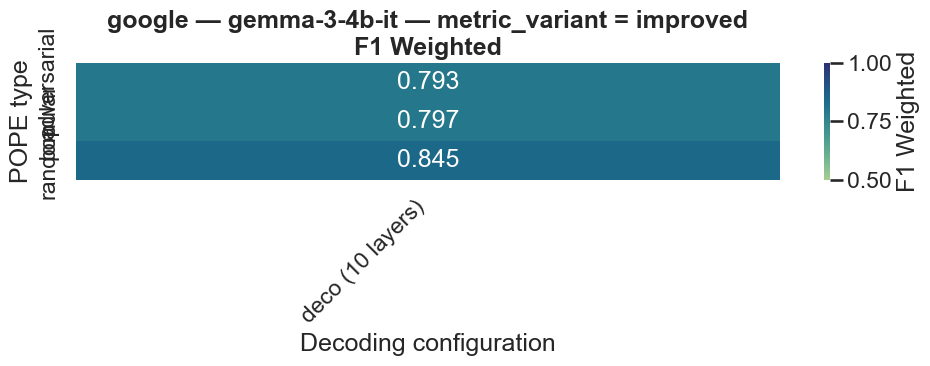

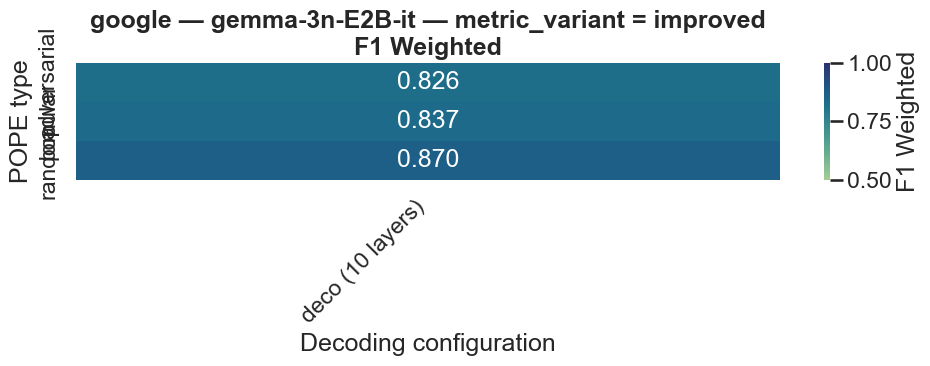

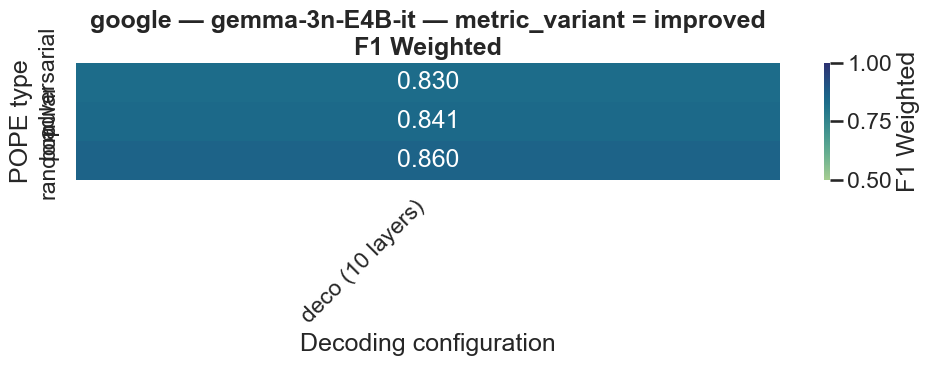

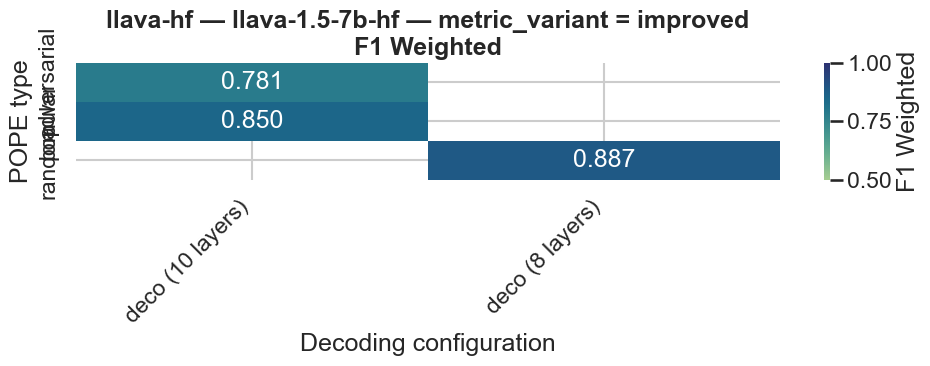

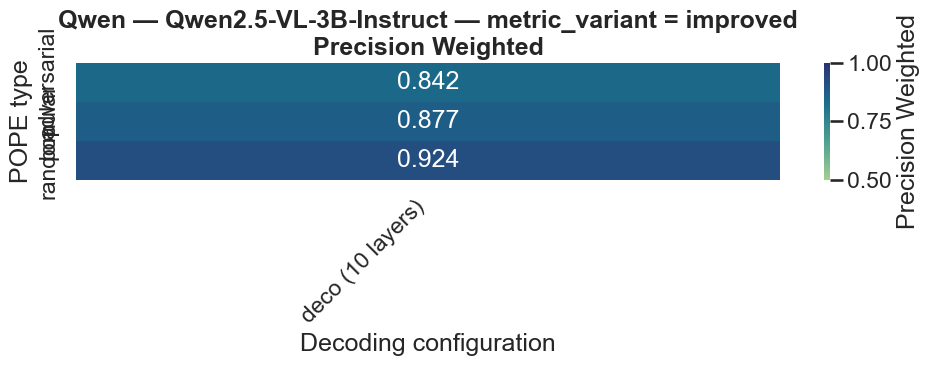

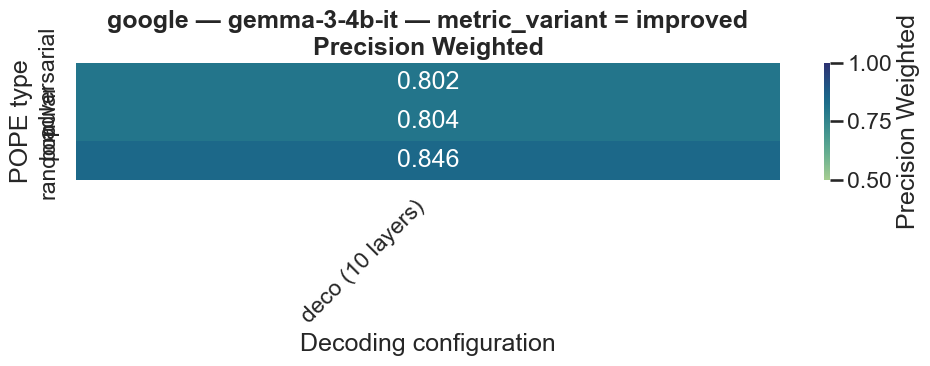

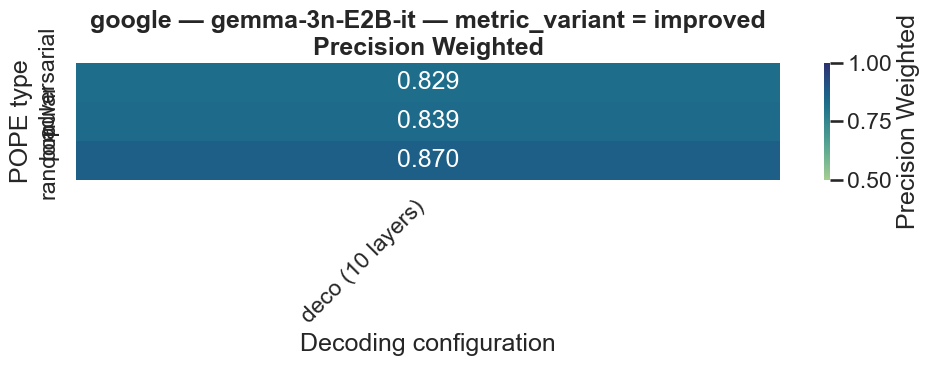

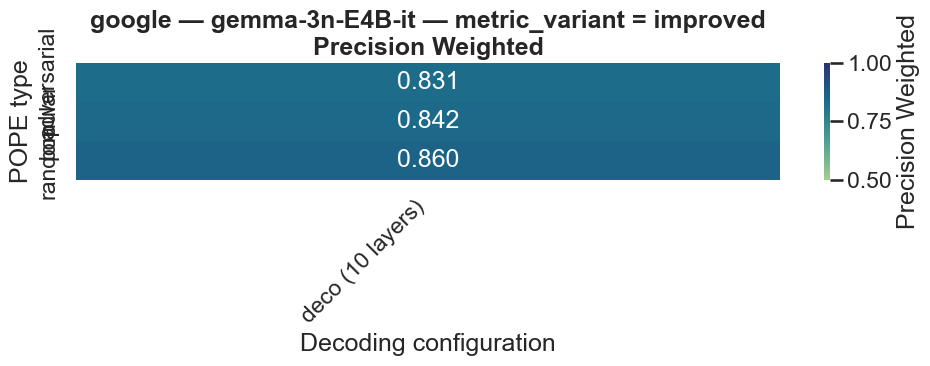

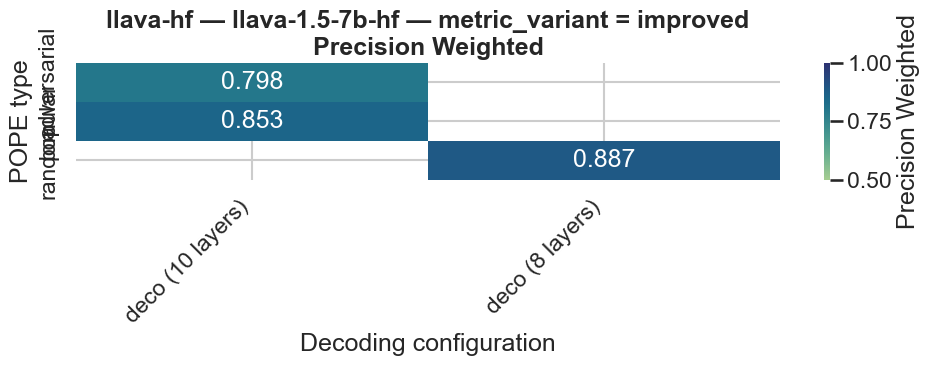

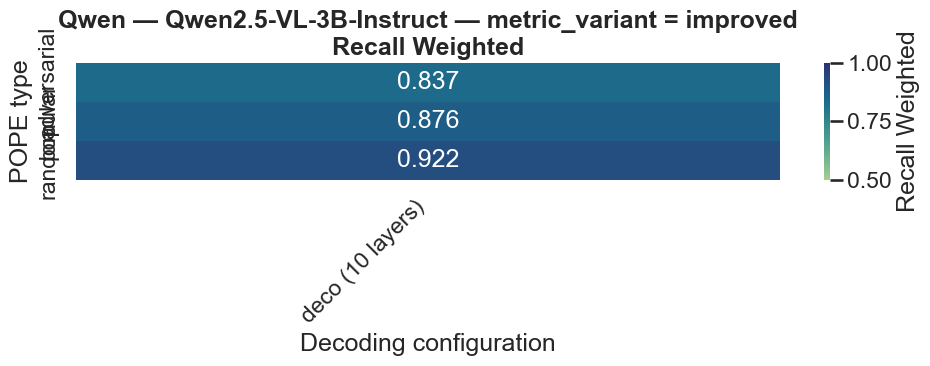

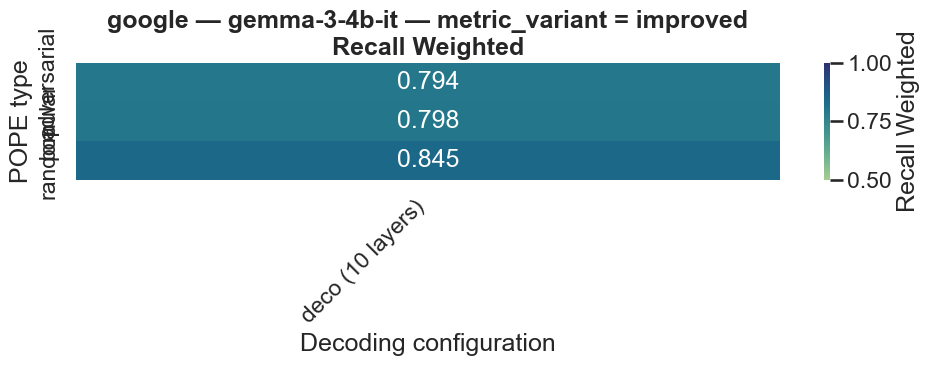

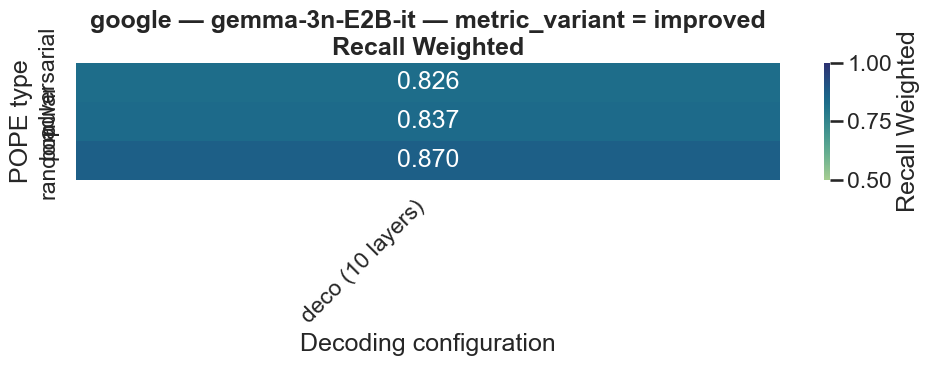

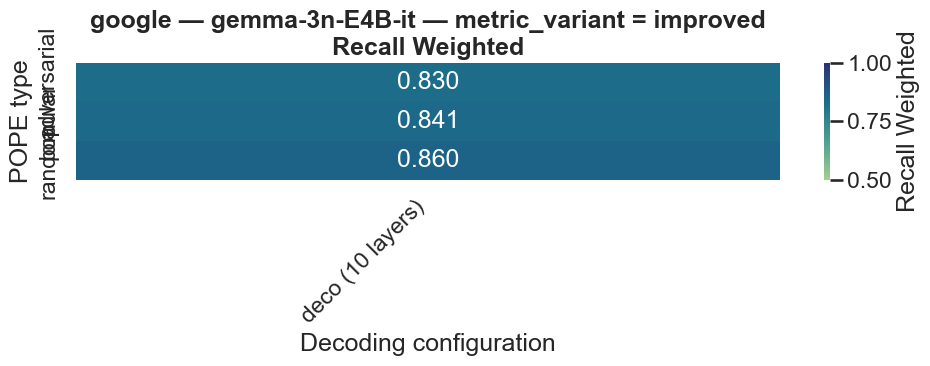

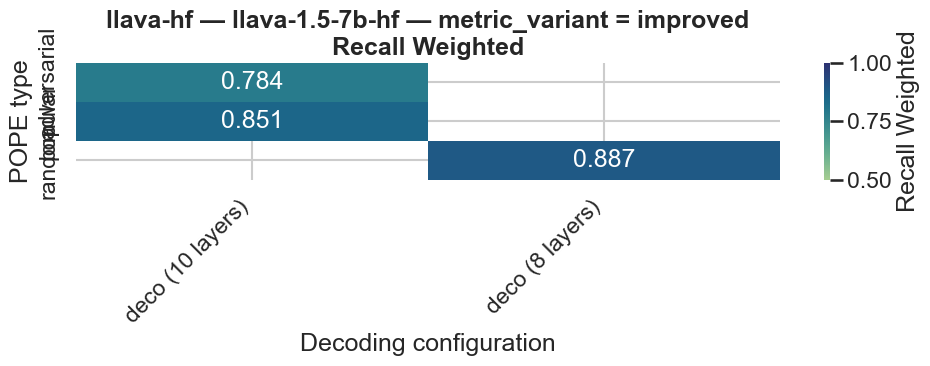

In [12]:
pope_metrics = ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"]

for metric_variant, subset_variant in pope_df.groupby("metric_variant"):
    for metric_name in pope_metrics:
        for (provider, model), subset in subset_variant.groupby(["provider", "model"]):
            pivot = subset.pivot(index="pope_type", columns="decoding", values=metric_name)
            pivot = pivot.loc[sorted(pivot.index)]
            pivot = pivot[sorted(pivot.columns, key=str.lower)]
            plt.figure(figsize=(10, 4))
            sns.heatmap(
                pivot,
                annot=True,
                fmt=".3f",
                cmap="crest",
                vmin=0.5 if metric_name != "accuracy" else 0.5,
                vmax=1.0,
                cbar_kws={"label": metric_name.replace('_', ' ').title()},
            )
            # keep the title on a single f-string line (use \n for a line break)
            plt.title(
                f"{provider} — {model} — metric_variant = {metric_variant}\n"
                f"{metric_name.replace('_', ' ').title()}"
            )
            plt.xlabel("Decoding configuration")
            plt.ylabel("POPE type")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
